## Preamble

In [1]:
import os
import time as tm
import datetime as dt
import random

# Data preparation
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For downloading the data from huggingface
from huggingface_hub import hf_hub_download
from datasets import load_dataset

# ML
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

# Graphics library
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# For loading environment variables
from dotenv import load_dotenv

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
REPO_ID = "johnrizzo1/stocks_daily_price"

# PatchTST Settings
INPUT_LEN = 60
FORECAST_LEN = 30
BATCH_SIZE = 64
EPOCHS = 50
PATCH_LEN = 15  # make sure INPUT_LEN % PATCH_LEN == 0
PATIENCE = 5
DELTA = 0.0001
NO_IMPROVEMENT_COUNT = 0
LEARNING_RATE = 0.001

## Data Preparation

In [3]:
ds = load_dataset(REPO_ID)
df = ds['train'].to_pandas()

In [4]:
# Filter for Ford stock and date range
df['date'] = pd.to_datetime(df['date'])
df = df[(df['symbol'] == 'AAPL') & (df['date'] >= '2010-01-01') & (df['date'] <= '2012-12-31')]
df = df.sort_values('date')

scaler = MinMaxScaler()
df['close_scaled'] = scaler.fit_transform(df[['close']])
data = df['close_scaled'].values

# Split the data into training and test data
train_data = data[:-90]
test_data = data[-(INPUT_LEN + FORECAST_LEN):]

In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, input_len, forecast_len):
        self.series = series
        self.input_len = input_len
        self.forecast_len = forecast_len

    def __len__(self):
        return len(self.series) - self.input_len - self.forecast_len

    def __getitem__(self, idx):
        x = self.series[idx:idx + self.input_len]
        y = self.series[idx + self.input_len:idx + self.input_len + self.forecast_len]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

In [6]:
train_dataset = TimeSeriesDataset(train_data, INPUT_LEN, FORECAST_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

## PatchTST for Equities

### Model Training

In [7]:
class PatchTST(nn.Module):
    def __init__(self, input_len, forecast_len, n_features, patch_len=16, n_heads=4, d_model=64, dropout=0.1):
        super().__init__()
        self.n_patches = input_len // patch_len
        self.patch_len = patch_len
        self.embedding = nn.Linear(patch_len * n_features, d_model)
        self.positional_encoding = nn.Parameter(torch.randn(1, self.n_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d_model * self.n_patches, forecast_len)
        )

    def forward(self, x):
        B, T, C = x.shape
        x = x.view(B, self.n_patches, self.patch_len * C)
        x = self.embedding(x) + self.positional_encoding[:, :self.n_patches]
        x = self.encoder(x)
        return self.head(x)

In [8]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False
    
    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [9]:
model = PatchTST(INPUT_LEN, FORECAST_LEN, n_features=1, patch_len=PATCH_LEN)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=PATIENCE, delta=DELTA)

In [10]:
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    val_loss = 0.0

    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss / len(train_loader):.4f}")

    # Validation phase
    model.eval()
    with torch.no_grad():
        for data, target in train_loader:
            data = data #.to(device)
            target = target #.to(device)
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
    
    # Average validation loss
    val_loss /= len(train_loader)

    # Check early stopping condition
    early_stopping.check_early_stop(val_loss)
    
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch}")
        break

Epoch 1/50, Loss: 0.1945
Epoch 2/50, Loss: 0.0703
Epoch 3/50, Loss: 0.0517
Epoch 4/50, Loss: 0.0327
Epoch 5/50, Loss: 0.0238
Epoch 6/50, Loss: 0.0195
Epoch 7/50, Loss: 0.0180
Epoch 8/50, Loss: 0.0166
Epoch 9/50, Loss: 0.0153
Epoch 10/50, Loss: 0.0139
Epoch 11/50, Loss: 0.0132
Epoch 12/50, Loss: 0.0124
Epoch 13/50, Loss: 0.0120
Epoch 14/50, Loss: 0.0114
Epoch 15/50, Loss: 0.0108
Epoch 16/50, Loss: 0.0098
Epoch 17/50, Loss: 0.0093
Epoch 18/50, Loss: 0.0088
Epoch 19/50, Loss: 0.0081
Epoch 20/50, Loss: 0.0080
Epoch 21/50, Loss: 0.0079
Epoch 22/50, Loss: 0.0070
Epoch 23/50, Loss: 0.0068
Epoch 24/50, Loss: 0.0062
Epoch 25/50, Loss: 0.0060
Epoch 26/50, Loss: 0.0055
Epoch 27/50, Loss: 0.0056
Epoch 28/50, Loss: 0.0054
Epoch 29/50, Loss: 0.0053
Epoch 30/50, Loss: 0.0051
Epoch 31/50, Loss: 0.0051
Epoch 32/50, Loss: 0.0050
Epoch 33/50, Loss: 0.0046
Epoch 34/50, Loss: 0.0043
Epoch 35/50, Loss: 0.0042
Epoch 36/50, Loss: 0.0041
Epoch 37/50, Loss: 0.0041
Epoch 38/50, Loss: 0.0041
Early stopping at epo

### Model Prediction

In [11]:
model.eval()
with torch.no_grad():
    test_input = torch.tensor(test_data[:INPUT_LEN], dtype=torch.float32).unsqueeze(0).unsqueeze(-1)
    pred_scaled = model(test_input).squeeze().numpy()

forecast_unscaled = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
actual_unscaled = scaler.inverse_transform(test_data[INPUT_LEN:].reshape(-1, 1)).flatten()
forecast_dates = pd.date_range(start=df['date'].max() + pd.Timedelta(days=1), periods=FORECAST_LEN)

forecast_30 = forecast_unscaled[-30:]
actual_30 = actual_unscaled[-30:]
forecast_dates_30 = forecast_dates[-30:]

In [12]:
mae = mean_absolute_error(actual_30, forecast_30)
r2 = r2_score(actual_30, forecast_30)
rmse = mean_squared_error(actual_30, forecast_30) ** 0.5

print("Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R^2: {r2:.4f}")

Evaluation Metrics:
MAE: 1.4738
RMSE: 1.7510
R^2: -2.3617


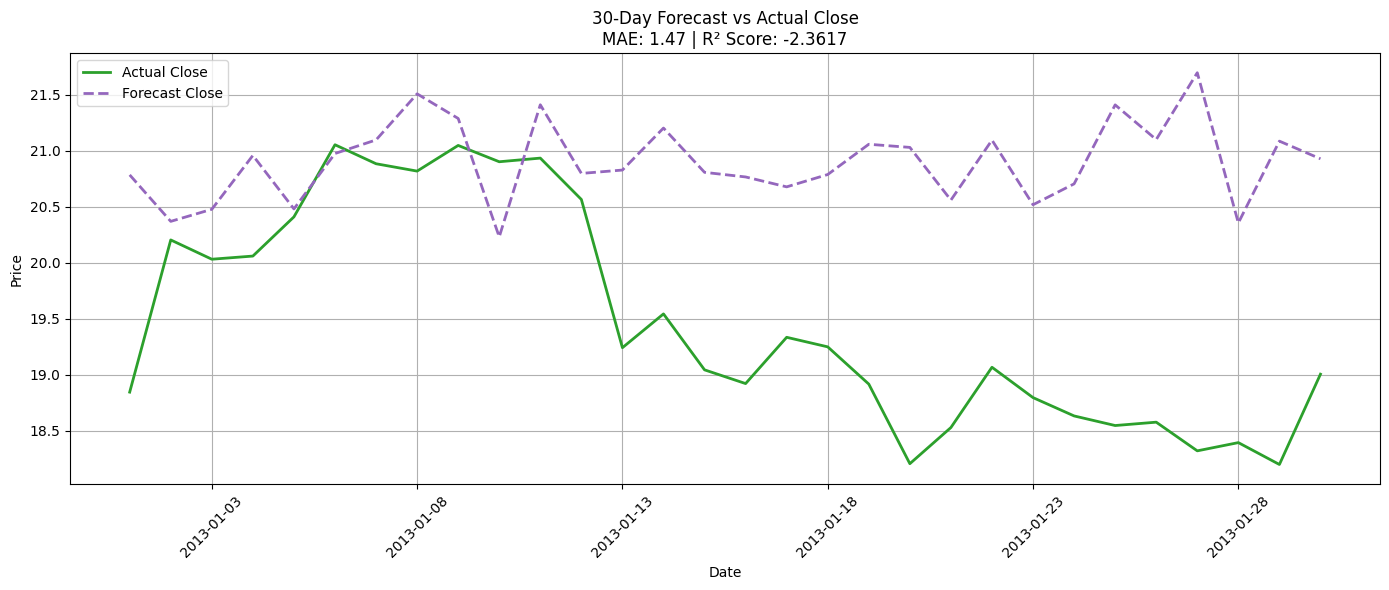

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(forecast_dates_30, actual_30, label='Actual Close', color='tab:green', linewidth=2)
plt.plot(forecast_dates_30, forecast_30, label='Forecast Close', color='tab:purple', linestyle='--', linewidth=2)
plt.title(f'30-Day Forecast vs Actual Close\nMAE: {mae:.2f} | R² Score: {r2:.4f}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.grid(True)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# PatchTST for Bonds

In [ ]:
INPUT_LEN = 90
# FORECAST_LEN = 30
# PATCH_LEN = 15
# BATCH_SIZE = 64
# EPOCHS = 50
LR = 0.0005

In [ ]:
# Loading the dataset for the Bonds data
folder_path = '/content/drive/My Drive/AAI-595/'
file_paths = [folder_path + "train-00000-of-00001.parquet"]
dfs = [pd.read_parquet(fp) for fp in file_paths]
df = pd.concat(dfs, ignore_index=True)

# This is choosing the date and year of the bond and the specific one being chosen
df = df[(df['symbol'] == 'US10Y') & (df['date'] >= '2010-01-01') & (df['date'] <= '2012-12-31')]
df = df.sort_values('date')
df['date'] = pd.to_datetime(df['date'])

# Moving averagers and rsi technical indicators
df['ma5'] = df['close'].rolling(5).mean()
df['ma20'] = df['close'].rolling(20).mean()
df['rsi'] = df['close'].diff().apply(lambda x: max(x, 0)).rolling(14).mean() / df['close'].diff().abs().rolling(14).mean()
df = df.fillna(method='bfill')

# Feature selection & scaling
features = ['open', 'high', 'low', 'close', 'volume', 'ma5', 'ma20', 'rsi']
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df[features].values)

In [ ]:
# Custom Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_len, forecast_len):
        self.data = data
        self.input_len = input_len
        self.forecast_len = forecast_len

    def __len__(self):
        return len(self.data) - self.input_len - self.forecast_len

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.input_len]
        y = self.data[idx + self.input_len:idx + self.input_len + self.forecast_len, 3]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [ ]:
train_dataset = TimeSeriesDataset(data_scaled, INPUT_LEN, FORECAST_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# PatchTST Model
class PatchTST(nn.Module):
    def __init__(self, input_len, forecast_len, n_features, patch_len=16, n_heads=8, d_model=128, dropout=0.1):
        super().__init__()
        self.n_patches = input_len // patch_len
        self.patch_len = patch_len
        self.embedding = nn.Sequential(
            nn.Linear(patch_len * n_features, d_model),
            nn.LayerNorm(d_model)
        )
        self.positional_encoding = nn.Parameter(torch.randn(1, self.n_patches, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(d_model * self.n_patches, forecast_len)
        )

    def forward(self, x):
        B, T, C = x.shape
        x = x.reshape(B, self.n_patches, self.patch_len * C)
        x = self.embedding(x) + self.positional_encoding[:, :self.n_patches]
        x = self.encoder(x)
        return self.head(x)

In [ ]:
# Training the data
model = PatchTST(INPUT_LEN, FORECAST_LEN, n_features=len(features), patch_len=PATCH_LEN)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [ ]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss / len(train_loader):.4f}")

In [ ]:
# Forecast
test_data = data_scaled[-(INPUT_LEN + FORECAST_LEN):]
model.eval()
with torch.no_grad():
    test_input = torch.tensor(test_data[:INPUT_LEN], dtype=torch.float32).unsqueeze(0)
    pred_scaled = model(test_input).squeeze().numpy()

forecast_unscaled = scaler.inverse_transform(
    np.concatenate([np.zeros((FORECAST_LEN, 3)),
                    pred_scaled.reshape(-1, 1),
                    np.zeros((FORECAST_LEN, len(features) - 4))], axis=1)
)[:, 3]

actual_unscaled = scaler.inverse_transform(
    np.concatenate([np.zeros((FORECAST_LEN, 3)),
                    test_data[INPUT_LEN:, 3].reshape(-1, 1),
                    np.zeros((FORECAST_LEN, len(features) - 4))], axis=1)
)[:, 3]

forecast_dates = pd.date_range(start=df['date'].max() + pd.Timedelta(days=1), periods=FORECAST_LEN)

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(forecast_dates, actual_unscaled, label='Actual Close', color='tab:green', linewidth=2)
plt.plot(forecast_dates, forecast_unscaled, label='Forecast Close', color='tab:blue', linestyle='--', linewidth=2)
plt.title('30-Day Forecast vs Actual Close Prices (Bonds)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()